In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve
from tqdm import tqdm
from sklearn.datasets import load_files
from pyvi import ViTokenizer
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

c:\Weekly_Hw_GR1\venv\Lib\site-packages\pyvi\ViTokenizer.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  model = pickle.load(fin)


In [2]:
base_dir = os.getcwd()
# tạo dir để lưu các hình ảnh
image_dir = os.path.join(base_dir, 'Ex8', 'data', 'images')
os.makedirs(image_dir, exist_ok = True)

In [3]:
news_dir = os.path.join(base_dir, 'Ex8', 'data', 'news_vnexpress')
os.listdir(news_dir)

['doi-song',
 'du-lich',
 'giai-tri',
 'giao-duc',
 'khoa-hoc',
 'kinh-doanh',
 'phap-luat',
 'suc-khoe',
 'the-thao',
 'thoi-su']

In [4]:
n = 0
for i in os.listdir(news_dir):
    print(f"{i}: {len(os.listdir(os.path.join(news_dir, i)))}")
    n+=len(os.listdir(os.path.join(news_dir, i)))
print(f"total article: {n}")

doi-song: 121
du-lich: 55
giai-tri: 202
giao-duc: 106
khoa-hoc: 145
kinh-doanh: 263
phap-luat: 59
suc-khoe: 163
the-thao: 174
thoi-su: 60
total article: 1348


In [5]:
# load data
data_train = load_files(container_path = news_dir, encoding = 'utf-8')

In [6]:
for ind, category in enumerate(data_train.target_names):
    print(f"{category} - {ind}")

doi-song - 0
du-lich - 1
giai-tri - 2
giao-duc - 3
khoa-hoc - 4
kinh-doanh - 5
phap-luat - 6
suc-khoe - 7
the-thao - 8
thoi-su - 9


In [7]:
len(data_train.data)

1348

In [8]:
stopword_dir = os.path.join(base_dir, 'Ex8', 'data', 'vietnamese-stopwords.txt')
with open(stopword_dir, 'r', encoding = 'utf-8') as f:
    stopwords = f.readlines()

stopwords

['a lô\n',
 'a ha\n',
 'ai\n',
 'ai ai\n',
 'ai nấy\n',
 'ai đó\n',
 'alô\n',
 'amen\n',
 'anh\n',
 'anh ấy\n',
 'ba\n',
 'ba ba\n',
 'ba bản\n',
 'ba cùng\n',
 'ba họ\n',
 'ba ngày\n',
 'ba ngôi\n',
 'ba tăng\n',
 'bao giờ\n',
 'bao lâu\n',
 'bao nhiêu\n',
 'bao nả\n',
 'bay biến\n',
 'biết\n',
 'biết bao\n',
 'biết bao nhiêu\n',
 'biết chắc\n',
 'biết chừng nào\n',
 'biết mình\n',
 'biết mấy\n',
 'biết thế\n',
 'biết trước\n',
 'biết việc\n',
 'biết đâu\n',
 'biết đâu chừng\n',
 'biết đâu đấy\n',
 'biết được\n',
 'buổi\n',
 'buổi làm\n',
 'buổi mới\n',
 'buổi ngày\n',
 'buổi sớm\n',
 'bà\n',
 'bà ấy\n',
 'bài\n',
 'bài bác\n',
 'bài bỏ\n',
 'bài cái\n',
 'bác\n',
 'bán\n',
 'bán cấp\n',
 'bán dạ\n',
 'bán thế\n',
 'bây bẩy\n',
 'bây chừ\n',
 'bây giờ\n',
 'bây nhiêu\n',
 'bèn\n',
 'béng\n',
 'bên\n',
 'bên bị\n',
 'bên có\n',
 'bên cạnh\n',
 'bông\n',
 'bước\n',
 'bước khỏi\n',
 'bước tới\n',
 'bước đi\n',
 'bạn\n',
 'bản\n',
 'bản bộ\n',
 'bản riêng\n',
 'bản thân\n',
 'bản ý\n',
 '

In [9]:
stopwords = [i.strip().replace(" ","_") for i in stopwords]
len(stopwords)

2063

In [10]:
module_count_vector = CountVectorizer(stop_words = stopwords)
model_tfidf = TfidfVectorizer(stop_words = stopwords)

In [11]:
data_preprocessed = model_tfidf.fit_transform(data_train.data, data_train.target)
data_preprocessed

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 212056 stored elements and shape (1348, 12788)>

In [12]:
# chia dataset theo hold out train test không giao nhau
X_train, X_test, y_train, y_test = train_test_split(data_preprocessed, data_train.target, test_size = 0.2, random_state = 36)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1078, 12788), (270, 12788), (1078,), (270,))

In [13]:
def cross_validation(estimator):
    train_sizes, train_scores, test_scores = learning_curve(estimator, X_train, y_train, cv = 10, n_jobs = -1, train_sizes = [1.0], scoring = 'accuracy')
    # đầu ra của train_scores và test_scores là ma trận 2d với số hàng là độ dài của train size số cột là số split trong cv
    # vì train size là 1 nên ma trận là ma trận 2d với đúng 1 hàng
    test_scores = test_scores[0]
    mean, std = test_scores.mean(), test_scores.std()
    return mean, std

In [14]:
def plot(title, xlabel, X, Y, error, ylabel = "Accuracy"):
    plt.xlabel(xlabel)
    plt.title(title)
    plt.grid()
    plt.ylabel(ylabel)
    plt.errorbar(X, Y, error, linestyle='None', marker='o')

100%|██████████| 2/2 [00:02<00:00,  1.11s/it]


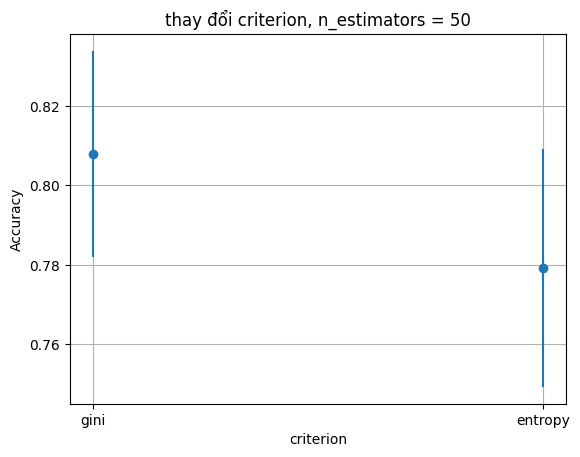

In [16]:
title = "thay đổi criterion, n_estimators = 50"
xlabel = "criterion"
X = []
Y = []
error = []
# lưu kết quả ra file ảnh
for criterion in tqdm(["gini", "entropy"]):
    text_clf = RandomForestClassifier(criterion=criterion, n_estimators=50)
    mean, std = cross_validation(text_clf)
    X.append(str(criterion))
    Y.append(mean)
    error.append(std)
plot(title, xlabel, X, Y, error)
plt.savefig(os.path.join(image_dir,'criterion.png'), bbox_inches='tight')
plt.show()

100%|██████████| 4/4 [00:08<00:00,  2.12s/it]


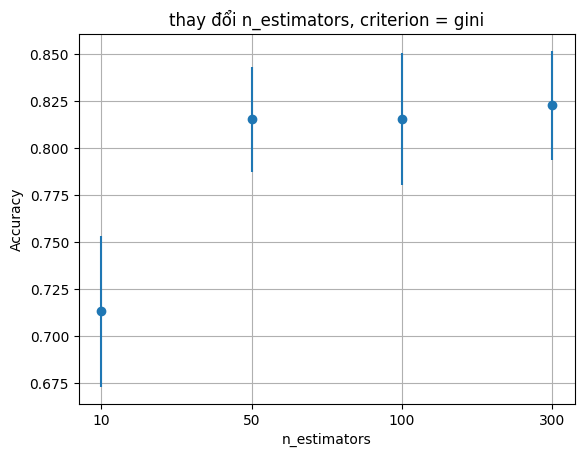

In [19]:
title = "thay đổi n_estimators, criterion = gini"
xlabel = "n_estimators"
X = []
Y = []
error = []
for n_estimators in tqdm([10, 50, 100, 300]):
# Với từng giá trị n_estimators nhận được,
# thực hiện xây dựng mô hình, huấn luyện và đánh giá theo cross-validation
    text_clf = RandomForestClassifier(criterion='gini', n_estimators=n_estimators)
    mean, std = cross_validation(text_clf)
    X.append(str(n_estimators))
    Y.append(mean)
    error.append(std)
# lưu kết quả ra file ảnh
plot(title, xlabel, X, Y, error)
plt.savefig(os.path.join(image_dir,'RF_change_N.png'), bbox_inches='tight')
plt.show()

100%|██████████| 4/4 [00:14<00:00,  3.74s/it]


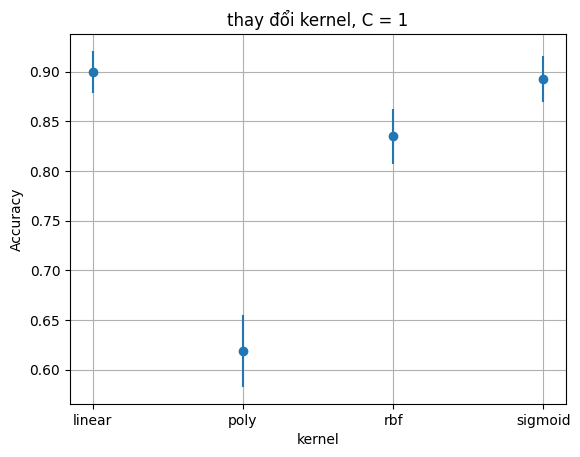

In [17]:
title = "thay đổi kernel, C = 1"
xlabel = "kernel"
X = []
Y = []
error = []
# lưu kết quả ra file ảnh
for kernel in tqdm(['linear', 'poly', 'rbf', 'sigmoid']):
# Với mỗi kernel được chọn,
# thực hiện xây dựng mô hình, huấn luyện và đánh giá theo cross-validation
    text_clf = svm.SVC(kernel=kernel, C=1.0)
    mean, std = cross_validation(text_clf)
    X.append(kernel)
    Y.append(mean)
    error.append(std)
plot(title, xlabel, X, Y, error)
plt.savefig(os.path.join(image_dir,'svm_change_kernel.png'), bbox_inches='tight')
plt.show()

100%|██████████| 5/5 [00:16<00:00,  3.33s/it]


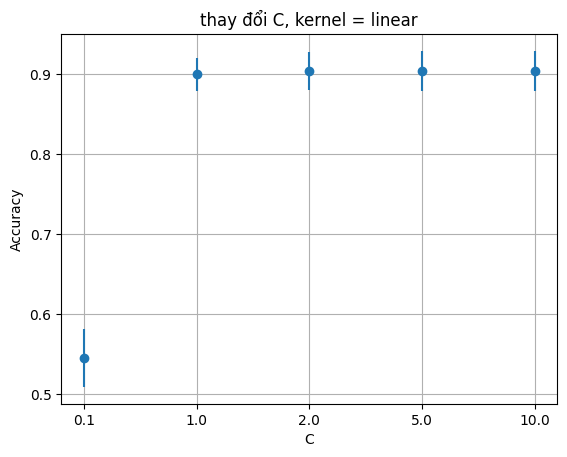

In [18]:
title = "thay đổi C, kernel = linear"
xlabel = "C"
X = []
Y = []
error = []
# lưu kết quả ra file ảnh
for C in tqdm([.1, 1.0, 2.0, 5.0, 10.0]):
# Với từng giá trị C nhận được,
# thực hiện xây dựng mô hình, huấn luyện và đánh giá theo cross-validation
    text_clf = svm.SVC(kernel='linear', C=C)
    mean, std = cross_validation(text_clf)
    X.append(str(C))
    Y.append(mean)
    error.append(std)
plot(title, xlabel, X, Y, error)
plt.savefig(os.path.join(image_dir,'svm_change_C.png'), bbox_inches='tight')
plt.show()